# Dateien Auslesen
In diesem Beispiel werden die Dateien zu einem gegebenen Pfad 
ausgelesen und ihre Metadaten, ihr Textcontent und ein Thumbnail in der Datenbank gespeichert.


## Settings

### Umgebungsvariablen setzen
Wichtig: Muss vor den Importen für meipi-indexing passieren\
Defaults werden aus config.env gelesen

In [1]:
import os
os.environ["IND_PG_SCHEMA"] = "public"
os.environ["IND_DATA_DIR"] = "/home/padmin/Development/projekte/meipi-indexing/data"

### Importe


In [2]:

import asyncio
from pprint import pprint
from tqdm.auto import tqdm
from itertools import batched
import sqlalchemy as sa
from meipi.indexing import Config, appconf, AsyncFileOperations, DBOperations, DBPool, DBMeta

/home/padmin/Development/projekte/meipi-indexing/.venv/lib/python3.14/site-packages/nvidia/dali/backend.py:96: Warning: Python 3.14 support is experimental and not officially tested.
  deprecation_warning("Python 3.14 support is experimental and not officially tested.")


### Weitere Settings

In [3]:
loop = asyncio.get_event_loop()
loop.set_task_factory(asyncio.eager_task_factory)

In [4]:
picroot = "/home/padmin/Bilder/Archiv/11 Bilder - sortiert archiv"
textroot = "/home/padmin/Dokumente"
textpool = DBPool(1,"Texte",textroot,"Pool für Textdateien")
picpool = DBPool(2,"Pics", picroot, "Pool für Bilder")
pool = picpool
relpath = "Bilder 2018"
#relpath = "01 Wichtige Dokumente"
incremental = True
pprint(appconf.model_dump())


{'datadir': './data',
 'docsuf': {'.doc',
            '.docx',
            '.epub',
            '.htm',
            '.html',
            '.md',
            '.odt',
            '.pdf',
            '.txt'},
 'envfile': 'config.env',
 'logger_name': 'sqlalchemy.engine',
 'loglevel': 20,
 'pg_api_key': 'pg-docker',
 'pg_database': 'postgres',
 'pg_host': 'localhost',
 'pg_passwd': 'postgres',
 'pg_port': '5432',
 'pg_schema': 'public',
 'pg_user': 'postgres',
 'picsuf': {'.tif', '.jpeg', '.bmp', '.heic', '.tiff', '.png', '.jpg'},
 'tika_noocr_url': 'http://localhost:9998',
 'tika_ocrurl': 'http://localhost:9997',
 'vidsuf': {'.mov', '.mp4', '.mkv', '.vob', '.avi', '.mcf'}}


### DB connect
Tabellen werden ggf. erzeugt, existierende werden nicht überschrieben

In [5]:
dbop = DBOperations(pool=pool,config=appconf)
pprint(dbop.schema_info())
dbop.create_tables()
with dbop.Session() as session:
    dbpool = session.get(DBPool, pool.id)
    if not dbpool:
        session.add(pool)
        session.flush()
        session.commit()
        print(f"Pool {pool.id} created")
    else:
        print(f"Pool {pool.id} already exists with values \n {dbpool}")
if not incremental:
    dbop.clear_pool()

{'schema': 'public',
 'tables': ['datapools',
            'filemeta',
            'documents',
            'pictures',
            'videos',
            'dino_v2_vectors']}
Pool 2 already exists with values 
 DBPool(id=2, pool='Pics2', rootpath='/home/padmin/Bilder/Archiv/11 Bilder - sortiert archiv', description='Pool für Bilder')


## Auslesen der Metadaten
### Lesen und asynchron parsen



In [8]:
#%%script true

async with AsyncFileOperations(pool, appconf) as afop:
    files = afop.dir_tree(relpath)
    if incremental:
        with dbop.Session() as session: 
            existing = session.scalars(sa.select(DBMeta.path).where(DBMeta.pool_id == pool.id)).all()
            files = [os.path.join(pool.rootpath,x) for x in files if x not in existing]    
    batches = batched(files, 500)
    for i, batch in tqdm(enumerate(batches)):
        tasklist = set()
        for file in batch:
            tasklist.add(asyncio.create_task(afop.file_to_db(file)))
        with dbop.Session() as session:
            async for task in asyncio.as_completed(tasklist):
                dbmeta = await task
                if dbmeta is not None:
                    session.add(dbmeta)
            session.flush()
            session.commit()

0it [00:00, ?it/s]

## Lesen

In [9]:
with dbop.Session() as session:
    res = session.scalars(sa.select(DBMeta).where(DBMeta.pool_id == pool.id,DBMeta.ftype == "doc")).all()
    pprint([x.doc for x in res[:10]])

[]


## Thumbs erzeugen

In [10]:
dbop.update_thumbs_no_heic()
dbop.update_thumbs_no_thumb()


DALI and large batch size: 0it [00:00, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

DALI and large batch size: 1 Bilder erfolgreich verarbeitet, 0 Bilder fehlgeschlagen


DALI and large batch size: 0it [00:00, ?it/s]

DALI and large batch size: 0 Bilder erfolgreich verarbeitet, 0 Bilder fehlgeschlagen


[]

## Thumbs anzeigen

P1020141.JPG


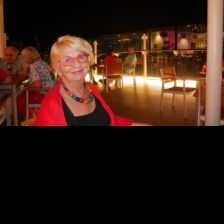

P1020252.JPG


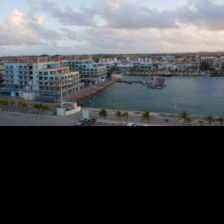

P1010258edt.jpg


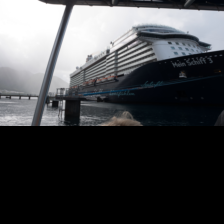

P1010844.JPG


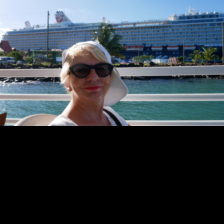

P1010423.JPG


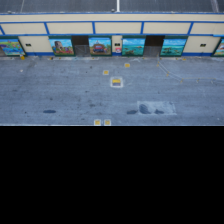

P1010437edt.jpg


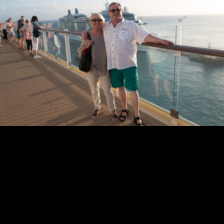

P1010476.JPG


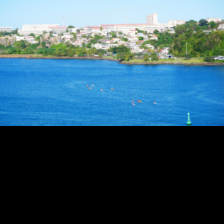

P1020197.JPG


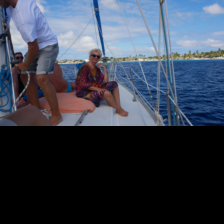

P1010272edt.jpg


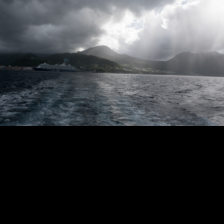

P1010517edt.jpg


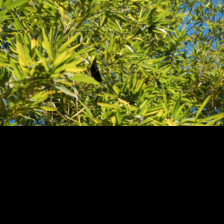

In [11]:
with dbop.Session() as session:
    res = session.scalars(sa.select(DBMeta).where(DBMeta.pool_id == pool.id,DBMeta.ftype == "pic")).all()
    for meta in res[:10]:
        print(meta.fname)
        display(meta.pic.thumb)